In [2]:
import librosa
import pathlib
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from numpy import pi as PI
from keras.layers import Dense
import matplotlib.pyplot as plt
from os import listdir, makedirs
from sklearn.utils import shuffle
from keras.models import Sequential
from os.path import join, exists, getsize
from tensorflow.keras.regularizers import l2
# from cmsisdsp import arm_cos_f32, arm_float_to_q15
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.initializers import RandomUniform
from keras.layers import Conv2D, MaxPooling2D, Flatten
# from cmsisdsp import arm_mult_q15, arm_rfft_instance_q15, arm_rfft_init_q15, arm_rfft_q15, arm_cmplx_mag_q15

2024-03-06 12:21:05.024223: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-06 12:21:05.025385: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-06 12:21:05.041767: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-06 12:21:05.041786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-06 12:21:05.042242: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
SAMPLING_FREQUENCY = 8000
MAX_LEN = 8000
WINDOW_SIZE = 256
STEP_SIZE = 128
NUM_WINDOWS = int(1 + (SAMPLING_FREQUENCY - WINDOW_SIZE) // STEP_SIZE)
NUM_FFT_BINS = int(WINDOW_SIZE // 2 + 1)

UNITS = 25
LEARNING_RATE = 0.01 
NUM_CLASSES = 2
EPOCHS = 20 
BATCH_SIZE = 32
# IN_SHAPE = (8000,)
IN_SHAPE = (61, 129)
VALIDATION_SIZE = 0.25

In [4]:
def create_folder(directory):
    if not exists(directory):
        makedirs(directory)

In [5]:
create_folder("./saved_models")
create_folder("./header_files")

In [6]:
DATA_PATH = "/home/icfoss/Datasets/kws_data/archive/"
CHECKPOINT_MODEL_PATH = join("./saved_models","dnn_model.keras")
SAVED_MODEL_PATH = "./saved_models"
TFLITE_MODEL_PATH = join("./saved_models","dnn_model.tflite")
TFLITE_OPT_MODEL_PATH = join("./saved_models","dnn_model_opt.tflite")

In [7]:
SELECTED_KEYWORDS = ["yes", "no"]
all_paths = []

yes_audios = listdir(join(DATA_PATH, "yes"))
no_audios = listdir(join(DATA_PATH, "no"))

for yes_audio in yes_audios:
    yes_path = join(join(DATA_PATH, "yes"), yes_audio)
    all_paths.append([yes_path, "yes"])

for no_audio in no_audios:
    no_path = join(join(DATA_PATH, "no"), no_audio)
    all_paths.append([no_path, "no"])
    
basic_data = pd.DataFrame(all_paths, columns=["Path", "Label"])

In [8]:
basic_data = shuffle(basic_data, random_state=33)
basic_data.loc[basic_data["Label"] == "yes", "Label"] = 1
basic_data.loc[basic_data["Label"] == "no", "Label"] = 0

In [9]:
stat = basic_data["Label"].value_counts()
print(stat*100/stat.sum())

Label
1    50.644959
0    49.355041
Name: count, dtype: float64


In [10]:
X = basic_data["Path"]
y = basic_data["Label"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=45, stratify=y)

In [11]:
def read_and_pad_seq(X, max_length=8000):
    X_seq = np.empty((0, max_length), float)
    for index, file_path in tqdm(X.items(), total = X.shape[0]): 
        audio_segment, _ = librosa.load(file_path, sr=8000)
        k = audio_segment.shape[0]
        if k>=max_length:
            audio_segment = audio_segment[:max_length]
        elif k<max_length:
            audio_segment = np.pad(audio_segment,(0,max_length-k),'constant')
        X_seq = np.vstack((X_seq, audio_segment))
    return X_seq

In [12]:
X_train_seq = read_and_pad_seq(X_train)
X_test_seq = read_and_pad_seq(X_test)

100%|███████████████████| 2396/2396 [00:21<00:00, 113.81it/s]


In [13]:
def create_hanning_window(WINDOW_SIZE):
    hanning_window_f32 = np.zeros(WINDOW_SIZE)
    for i in range(WINDOW_SIZE):
        hanning_window_f32[i] = 0.5 * (1 - arm_cos_f32(2 * PI * i / WINDOW_SIZE ))
    hanning_window_q15 = arm_float_to_q15(hanning_window_f32)
    return hanning_window_q15

In [14]:
hanning_window = np.hanning(WINDOW_SIZE)

def compute_spectrogram_new(raw_data, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window):
    spectrogram = np.empty((NUM_WINDOWS, NUM_FFT_BINS))
    for index in range(NUM_WINDOWS):
        window_start = index*STEP_SIZE
        window_end = window_start+WINDOW_SIZE
        window = raw_data[window_start:window_end]
        processed_window = window * hanning_window
        raw_fft = np.fft.rfft(processed_window)
        spectrogram[index] = np.abs(raw_fft)
    return spectrogram

In [15]:
# hanning_window_q15 = create_hanning_window(WINDOW_SIZE)
# rfft_instance_q15 = arm_rfft_instance_q15()

# def compute_spectrogram_arm(raw_data, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window_q15, rfft_instance_q15):
#     audio_samples_q15 = arm_float_to_q15(raw_data)
#     spectrogram_q15 = np.empty((NUM_WINDOWS, NUM_FFT_BINS))
#     start_index = 0
#     for index in range(NUM_WINDOWS):
#       audio_window_q15 = audio_samples_q15[start_index:start_index + WINDOW_SIZE]
#       processed_audio_q15 = arm_mult_q15(audio_window_q15, hanning_window_q15)
#       rfft_q15 = arm_rfft_q15(rfft_instance_q15, processed_audio_q15)
#       rfft_mag_q15 = arm_cmplx_mag_q15(rfft_q15)[:NUM_FFT_BINS]
#       spectrogram_q15[index] = rfft_mag_q15
#       start_index += STEP_SIZE
#     return spectrogram_q15

In [16]:
def convert_to_spectrogram(X_seq, hanning_window_q15):
    X_spectrogram = []
    for row in tqdm(X_seq):
        spectrum = compute_spectrogram_new(row, NUM_WINDOWS, NUM_FFT_BINS, STEP_SIZE, WINDOW_SIZE, hanning_window) 
        X_spectrogram.append(spectrum)
    X_spectrogram = np.asarray(X_spectrogram)
    return X_spectrogram

X_train_spectrogram = convert_to_spectrogram(X_train_seq, hanning_window)
X_test_spectrogram = convert_to_spectrogram(X_test_seq, hanning_window)

100%|██████████████████| 2396/2396 [00:00<00:00, 6685.18it/s]


In [17]:
class LossHistory(tf.keras.callbacks.Callback):
    def __init__(self,validation_data): 
        self.x_test = validation_data[0] 
        self.y_test= validation_data[1]
        
def on_train_begin(self, logs={}):
    self.history={'loss': [],'accuracy': [],'val_loss': [],'val_accuracy': [],'val_f1': []}
    
def on_epoch_end(self, epoch, logs={}):
    self.history['loss'].append(logs.get('loss')) 
    self.history['accuracy'].append(logs.get('accuracy'))
    
    if logs.get('val_loss', -1) != -1: 
        self.history['val_loss'].append(logs.get('val_loss'))
    if logs.get('val_accuracy', -1) != -1: 
        self.history['val_accuracy'].append(logs.get('val_accuracy'))
        
    y_pred= self.model.predict(self.x_test)
    y_label_pred = np.argmax(y_pred,axis=1) 
    y_test_arg = self.y_test
    F1 = f1_score(y_test_arg, y_label_pred, average='micro')
    self.history['val_f1'].append(F1)
    print(' Val F1 Score : ', np.round(F1,4))

In [18]:
adam_opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE,
                                   beta_1=0.9,
                                   beta_2=0.999,
                                   epsilon=1e-8)

2024-03-06 12:23:25.186970: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-03-06 12:23:25.187157: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [19]:
def myDNN(in_shape, adam_opt):
    model = Sequential()
    model.add(Dense(8, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='relu'))
    model.add(Flatten())
    model.add(Dense(16, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='relu'))
    model.add(Dense(2, kernel_initializer=RandomUniform(minval=-0.05,
                    maxval=0.05), kernel_regularizer=l2(0.001),
                    activation='softmax'))
    model.compile(optimizer= adam_opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [20]:
cp_callback = ModelCheckpoint(filepath=SAVED_MODEL_PATH,
                              monitor="val_accuracy",
                              verbose=1,
                              save_best_only=True,
                              mode="max")

In [21]:
dnn_model = myDNN(IN_SHAPE, adam_opt)

In [22]:
history = dnn_model.fit(X_train_spectrogram,
                        y_train,
                        batch_size=BATCH_SIZE,
                        epochs=EPOCHS,
                        validation_data=(X_test_spectrogram, y_test),
                        callbacks=[cp_callback])

Epoch 1/20
140/175 [=======================>......] - ETA: 0s - loss: 0.3628 - accuracy: 0.8759
Epoch 1: val_accuracy improved from -inf to 0.93447, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 1s 3ms/step - loss: 0.3490 - accuracy: 0.8810 - val_loss: 0.2565 - val_accuracy: 0.9345
Epoch 2/20
151/175 [========================>.....] - ETA: 0s - loss: 0.2494 - accuracy: 0.9321
Epoch 2: val_accuracy did not improve from 0.93447
175/175 [==============================] - 0s 901us/step - loss: 0.2499 - accuracy: 0.9345 - val_loss: 0.3204 - val_accuracy: 0.9040
Epoch 3/20
159/175 [==========================>...] - ETA: 0s - loss: 0.2501 - accuracy: 0.9346
Epoch 3: val_accuracy did not improve from 0.93447
175/175 [==============================] - 0s 919us/step - loss: 0.2477 - accuracy: 0.9343 - val_loss: 0.2710 - val_accuracy: 0.9257
Epoch 4/20
142/175 [=======================>......] - ETA: 0s - loss: 0.2076 - accuracy: 0.9485
Epoch 4: val_accuracy improved from 0.93447 to 0.94658, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 0s 2ms/step - loss: 0.2036 - accuracy: 0.9495 - val_loss: 0.2085 - val_accuracy: 0.9466
Epoch 5/20
159/175 [==========================>...] - ETA: 0s - loss: 0.2058 - accuracy: 0.9471
Epoch 5: val_accuracy did not improve from 0.94658
175/175 [==============================] - 0s 852us/step - loss: 0.2055 - accuracy: 0.9472 - val_loss: 0.2721 - val_accuracy: 0.9399
Epoch 6/20
165/175 [===========================>..] - ETA: 0s - loss: 0.2243 - accuracy: 0.9509
Epoch 6: val_accuracy did not improve from 0.94658
175/175 [==============================] - 0s 1ms/step - loss: 0.2246 - accuracy: 0.9508 - val_loss: 0.2528 - val_accuracy: 0.9386
Epoch 7/20
135/175 [======================>.......] - ETA: 0s - loss: 0.2263 - accuracy: 0.9519
Epoch 7: val_accuracy improved from 0.94658 to 0.95701, saving model to ./saved_models
INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


175/175 [==============================] - 0s 3ms/step - loss: 0.2265 - accuracy: 0.9513 - val_loss: 0.2221 - val_accuracy: 0.9570
Epoch 8/20
143/175 [=======================>......] - ETA: 0s - loss: 0.2159 - accuracy: 0.9532
Epoch 8: val_accuracy did not improve from 0.95701
175/175 [==============================] - 0s 945us/step - loss: 0.2174 - accuracy: 0.9538 - val_loss: 0.2315 - val_accuracy: 0.9470
Epoch 9/20
117/175 [===================>..........] - ETA: 0s - loss: 0.1937 - accuracy: 0.9570
Epoch 9: val_accuracy did not improve from 0.95701
175/175 [==============================] - 0s 1ms/step - loss: 0.2041 - accuracy: 0.9542 - val_loss: 0.2547 - val_accuracy: 0.9412
Epoch 10/20
159/175 [==========================>...] - ETA: 0s - loss: 0.2001 - accuracy: 0.9538
Epoch 10: val_accuracy did not improve from 0.95701
175/175 [==============================] - 0s 2ms/step - loss: 0.2014 - accuracy: 0.9520 - val_loss: 0.2183 - val_accuracy: 0.9453
Epoch 11/20
142/175 [==========

In [23]:
dnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 61, 8)             1040      
                                                                 
 flatten (Flatten)           (None, 488)               0         
                                                                 
 dense_1 (Dense)             (None, 16)                7824      
                                                                 
 dense_2 (Dense)             (None, 2)                 34        
                                                                 
Total params: 8898 (34.76 KB)
Trainable params: 8898 (34.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
def qualityLinePlot(history, labelsize=12, width=5):
    plt.rc("font", family="serif")
    plt.rc("xtick", labelsize=labelsize)
    plt.rc("ytick", labelsize=labelsize)
    plt.rc("axes", labelsize=labelsize)

    height = width / 1.618
    fig1, ax1 = plt.subplots()
    fig1.subplots_adjust(left=0.16, bottom=0.2, right=0.99, top=0.90)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

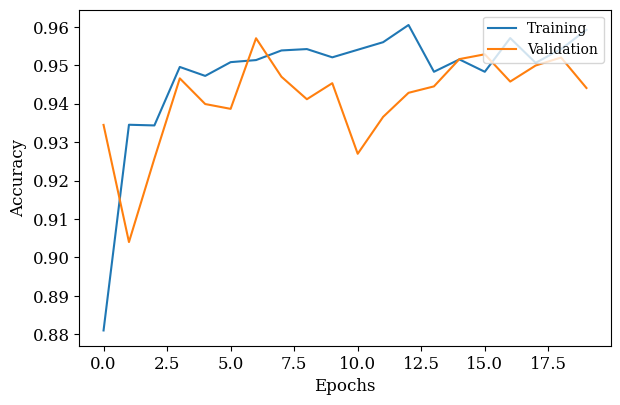

In [25]:
qualityLinePlot(history)

In [26]:
tf.saved_model.save(dnn_model, SAVED_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_PATH)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path(TFLITE_MODEL_PATH)
model_size_kb = tflite_model_file.write_bytes(tflite_model) /  1024
print("Size of TensorFlow Lite Model: {} KB:".format(model_size_kb))

converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_opt = converter.convert()

tflite_model_opt_1 = pathlib.Path(TFLITE_OPT_MODEL_PATH)
model_size_kb_opt = tflite_model_opt_1 .write_bytes(tflite_model_opt) /  1024
print("Size of TensorFlow Lite Opt Model: {} KB:".format(model_size_kb_opt))

size_reduction = np.round(model_size_kb / model_size_kb_opt, 1)
print("There is {}x reduction in size".format(size_reduction))

INFO:tensorflow:Assets written to: ./saved_models/assets


INFO:tensorflow:Assets written to: ./saved_models/assets


Size of TensorFlow Lite Model: 39.08203125 KB:
Size of TensorFlow Lite Opt Model: 13.3125 KB:
There is 2.9x reduction in size


2024-03-06 12:23:31.615604: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2024-03-06 12:23:31.615619: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2024-03-06 12:23:31.615759: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: ./saved_models
2024-03-06 12:23:31.616153: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2024-03-06 12:23:31.616158: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: ./saved_models
2024-03-06 12:23:31.617507: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2024-03-06 12:23:31.617896: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2024-03-06 12:23:31.639136: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: ./saved_models
2024-03-06 12

In [27]:
!echo "const unsigned char model[] = {" > header_files/model.h
!cat saved_models/dnn_model_opt.tflite | xxd -i >> header_files/model.h
!echo "};" >> header_files/model.h

model_h_size = getsize("./saved_models/dnn_model_opt.tflite")
print(f"Header file, model.h, is {model_h_size:,} bytes.")

Header file, model.h, is 13,632 bytes.
